In [18]:
import scipy.linalg as linal
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

In [19]:
data1 = scipy.io.loadmat(r'ipca model/flowdata1.mat')
data2 = scipy.io.loadmat(r'ipca model/flowdata2.mat')
data3 = scipy.io.loadmat(r'ipca model/flowdata3.mat')

In [20]:
np.shape(data3['Fmeas'])

(1000, 5)

### <u>STRUCTURE OF DATA</u> : 
| **VARIABLE** | **PURPOSE** | **DATA 1** | **DATA 2** | **DATA 3** |
| :--------: | ------- | :-----: | :-----: | :-----: | 
| Atrue    | Contains the true relationship matrix | YES | YES | YES |
| Fmeas    | Contains the measured data | YES | YES | YES |
| Ftrue    | Contains the Denoised data ( *deterministic part of data* ) that follows $ ZA^{T} = 0 $ | YES | YES | NO |
| std      | Contains the Standard Deviation ($\sigma$) for each of the 5 variables | YES | YES | YES | 

---
#### PART 1 : 
* Number of Constraints = 3 
* Errors in variables are independent, the Error Covariance Matrix is diagonal
* Apply IPCA to estimate this Error Covariance ( $\Sigma_{e}$ ) and the Constraint Matrix ( $A$ )

In [21]:
Z1 = data1['Fmeas']
Z2 = data2['Fmeas']
Z3 = data3['Fmeas']

N = 1000 # Number of Samples
p = 5    # Number of Flow Parameters ( Variables )
m = 3    # Number of Constraints 

mean_shift = lambda x : x - x.mean(axis=0)

In [111]:
class stdtest : 

    def __init__(self, Y, m=3) :
        self.Y = mean_shift(Y).T
        self.m = m
        self.N, self.p = np.shape(Y)
        self.sd = np.diag(np.ones(self.p))
        self.evals = linal.svd(Y/np.sqrt(self.N)) [1] ** 2 

    def compute_sd(self) :
        
        m,p,N = self.m, self.p, self.N
        G = np.kron(self.A, self.A) [:,::(p+1)]
        # R = self.A @ ( linal.inv(self.sd) @ self.Y ) 
        R = self.A @ self.Y
        
        V = R @ R.T / N
        vecV = V.T.reshape((m*m, 1))

        var = np.abs(linal.inv(G.T@G)@G.T@vecV)
        sd  = np.diag(np.sqrt(var).T[0])
        self.sd = sd

        return sd
    
    def compute_A(self) :
        scaled_data = self.Y.T @ linal.inv(self.sd).T/np.sqrt(np.shape(self.Y) [1])
        self.evals = linal.svd(scaled_data) [1] ** 2 
        self.A = ( linal.svd(scaled_data) [2].T [:, -self.m:].T ) @ np.linalg.inv(self.sd)
        return self.A

In [186]:
Z    = Z1
dat2 = stdtest(Z)

var = np.empty((1,5))
for i in range(5) : 
    dat2.compute_A()
    dat2.compute_sd()
    stds = np.diag(dat2.sd) [np.newaxis]
    var = np.append(var, stds, axis=0)

var = np.delete(var,0,axis=0)


Text(0.5, 1.0, 'variation of cholesky factor elements with ipca')

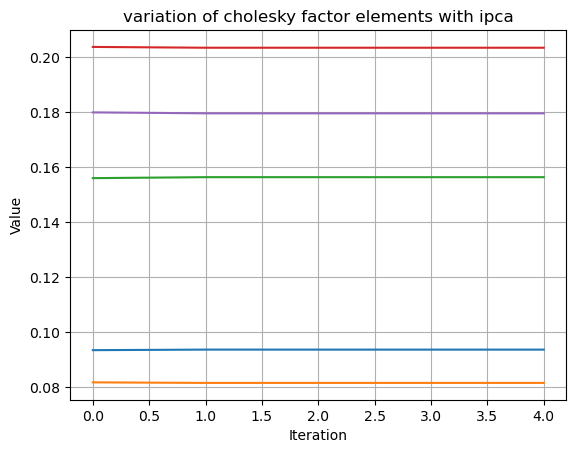

In [187]:
plt.plot(var)        
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title('variation of cholesky factor elements with ipca')

In [188]:
print(data2['std'].T)

[[0.1  0.08 0.15 0.2  0.18]]


In [189]:
print("CHOLESKY MATRIX : ")
print(np.round(dat2.sd,4))
print("-------------------------------------------------------")
print()
print("CONVERGED CONSTRAINT MATRIX : ")
print(np.round(dat2.A,4))
# print("-------------------------------------------------------")
print()
print("CONVERGED EIGENVECTORS :")
print(np.round(dat2.A @ np.linalg.inv(dat2.sd),4))
print("-------------------------------------------------------")
At = data2['Atrue']
true_regression = -np.linalg.inv(At[:,[2,3,4]])@At[:,[0,1]]
A =dat2.A
converged_regression = -np.linalg.inv(A[:,[2,3,4]])@A[:,[0,1]]

print()
print("TRUE REGRESSION MATRIX :")
print(true_regression)
# print("-------------------------------------------------------")
print()
print("CONVERGED REGRESSION MATRIX :")
print(np.round(converged_regression,4))
# print("-------------------------------------------------------")
print()
print("ABSOLUTE DIFFERENCE BETWEEN THE REGRESSION MATRICES :")
print(np.round(np.abs(true_regression - converged_regression),4))


CHOLESKY MATRIX : 
[[0.0937 0.     0.     0.     0.    ]
 [0.     0.0816 0.     0.     0.    ]
 [0.     0.     0.1564 0.     0.    ]
 [0.     0.     0.     0.2034 0.    ]
 [0.     0.     0.     0.     0.1796]]
-------------------------------------------------------

CONVERGED CONSTRAINT MATRIX : 
[[-3.4973  0.003   2.7449 -2.7619  3.4889]
 [ 4.6006  5.8715 -3.712  -2.1815  1.2529]
 [-3.4973  0.0119 -2.7449  2.7619  3.4889]]

CONVERGED EIGENVECTORS :
[[-37.3223   0.0365  17.5516 -13.5756  19.4262]
 [ 49.0967  71.9539 -23.7353 -10.7229   6.9761]
 [-37.3224   0.146  -17.5517  13.5756  19.4262]]
-------------------------------------------------------

TRUE REGRESSION MATRIX :
[[1. 1.]
 [1. 1.]
 [1. 0.]]

CONVERGED REGRESSION MATRIX :
[[ 0.996   0.9987]
 [ 0.9899  0.9909]
 [ 1.0024 -0.0021]]

ABSOLUTE DIFFERENCE BETWEEN THE REGRESSION MATRICES :
[[0.004  0.0013]
 [0.0101 0.0091]
 [0.0024 0.0021]]


In [190]:
data3['Atrue']

array([[ 1,  1, -1,  0,  0],
       [ 0,  0,  1, -1,  0],
       [ 0, -1,  0,  1, -1]], dtype=int16)

* Results show that when considering there is no non diagonal elements in the error covariance matrix, no convergence is obtained for the constraint matrix and the standard deviation matrix using ipca
---
### PART 2

In [191]:
from scipy.stats.distributions import chi2

In [192]:
class smallest_eigenvalues(stdtest) : 
    def hypothesis_testing(self) : 
        p = self.p
        d = p-1
        N = self.N
        
        # self.evals = np.sort(linal.eig(np.linalg.inv(self.sd)@self.Y @ self.Y.T @ np.linalg.inv(self.sd.T))/ N) [0].real [::-1]
        # print(np.round(self.evals,4))

        while d > 1 : 
            n_dash = N - (2*p+11)/6
            l_dash = self.evals[ p-d : ].sum()/d 

            tau    = n_dash * ( d * np.log(l_dash) - np.log(self.evals[ p-d : ]).sum())

            fdom   = 0.5*(d+2)*(d-1)
            chi    = chi2.ppf(0.95, df=fdom)

            if (tau <= chi) : 
                print()
                print("Detected Number of Constraints :", d)
                break 
            else : 
                d = d - 1 
            
            print("------------------------------------------------------")
            print(d+1, '| Test Statistic :', np.round(tau,3),'\t Chi2 Value :', np.round(chi,3))
        self.m = d 

In [193]:
np.set_printoptions(suppress=True)
for m in range(1,5) : 
    expt1 = smallest_eigenvalues(Z3,m)
    print("Number of Constraints (m) for ipca :", m)
    # expt1.hypothesis_testing()

    var = []
    for i in range(10) : 
        expt1.compute_A()
        # print(i)
        expt1.compute_sd()
        var.append(expt1.sd[0])

    expt1.hypothesis_testing()
    print("------------------------------------------------------")
    print()

Number of Constraints (m) for ipca : 1
------------------------------------------------------
4 | Test Statistic : 4670.254 	 Chi2 Value : 16.919
------------------------------------------------------
3 | Test Statistic : 2629.441 	 Chi2 Value : 11.07
------------------------------------------------------
2 | Test Statistic : 33.273 	 Chi2 Value : 5.991
------------------------------------------------------

Number of Constraints (m) for ipca : 2
------------------------------------------------------
4 | Test Statistic : 9573.539 	 Chi2 Value : 16.919
------------------------------------------------------
3 | Test Statistic : 2951.348 	 Chi2 Value : 11.07
------------------------------------------------------
2 | Test Statistic : 1121.856 	 Chi2 Value : 5.991
------------------------------------------------------

Number of Constraints (m) for ipca : 3
------------------------------------------------------
4 | Test Statistic : 6336.625 	 Chi2 Value : 16.919
----------------------------

Text(0, 0.5, 'value')

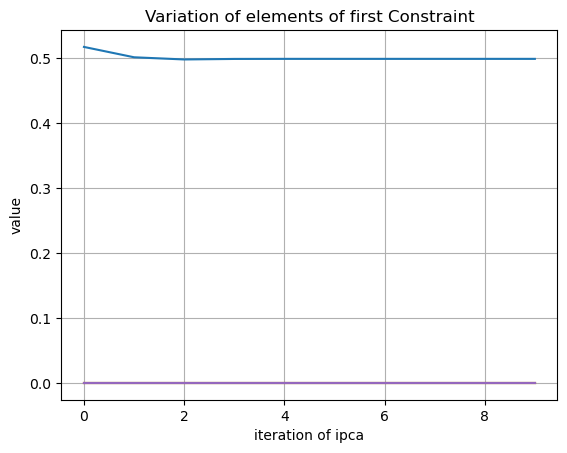

In [194]:
plt.plot(var)
plt.title('Variation of elements of first Constraint')
plt.grid()
plt.xlabel('iteration of ipca')
plt.ylabel('value')

* From the above plot we can see that no convergence has been achieved in the datas of the constraint matrix
* From the statistical testing we get that there not even two eigenvalues that comprise the null space of the matrix 
* All these tell us that there are non diagonal elements present in the error covariance matrix which will affect the scaling of the data matrix 
____
### PART 3 : 
in Assingment_5.ipynb